In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# For 2D Data

In [ ]:
x,y = make_regression(n_samples = 100,n_features=1,n_informative=1,n_targets=1,noise = 20,random_state = 12)

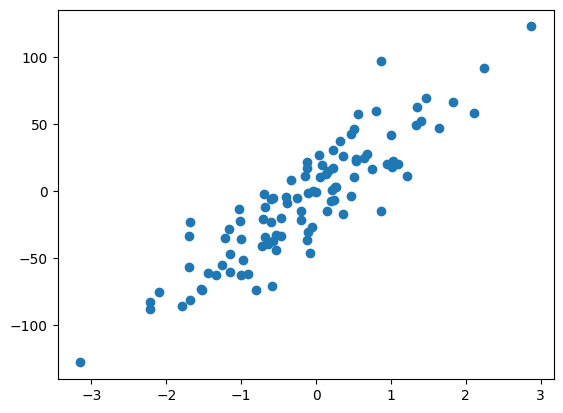

In [ ]:
plt.scatter(x,y)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 12)

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[38.90176409]
-1.1445473328809923


In [ ]:
rr = Ridge(alpha = 10)
rr.fit(x_train,y_train)


Ridge(alpha=10)

In [ ]:
print(rr.coef_)
print(rr.intercept_)

[34.41976055]
-1.8570261528653305


In [ ]:
rr1 = Ridge(alpha = 100)
rr1.fit(x_train,y_train)


Ridge(alpha=100)

In [ ]:
print(rr1.coef_)
print(rr1.intercept_)

[16.89794109]
-4.642370948784946


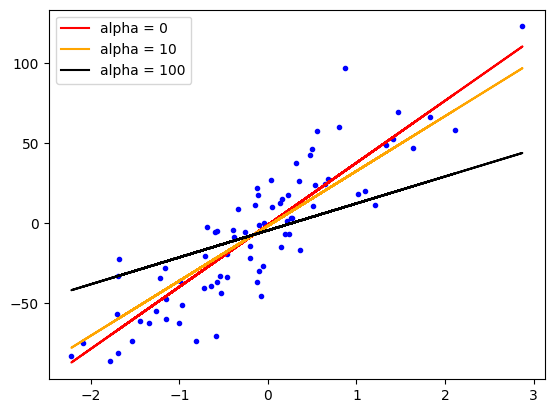

In [ ]:
plt.plot(x_train,y_train,'b.')
plt.plot(x_train,lr.predict(x_train),color ='red',label='alpha = 0')
plt.plot(x_train,rr.predict(x_train),color = 'orange',label='alpha = 10')
plt.plot(x_train,rr1.predict(x_train),color = 'black',label='alpha = 100')
plt.legend()

In [ ]:
class MearRidge:

    def __init__(self,alpha = 0.1):
        self.m = 0
        self.b = 0
        self.alpha = alpha

    def fit(self,x_train,y_train):

        num = 0
        den = 0

        for i in range(x_train.shape[0]):

            num = num + (y_train[i] - y_train.mean()) * (x_train[i] - x_train.mean())
            den = den + (x_train[i] - x_train.mean())**2

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m * x_train.mean())

        print(self.m)
        print(self.b)

    def predict(self,x_test):
        return self.m * x_test + self.b


In [ ]:
mr = MearRidge(10)
mr.fit(x_train,y_train)

[34.41976055]
[-1.85702615]


In [ ]:
print('Linear Regression :-',r2_score(y_test,lr.predict(x_test)))
print('Ridge Regression (alpha = 10) :-',r2_score(y_test,rr.predict(x_test)))
print('Scratch Ridge Regression (alpha = 10) :-',r2_score(y_test,mr.predict(x_test)))
print('Ridge Regression (alpha = 100) :-',r2_score(y_test,rr1.predict(x_test)))


Linear Regression :- 0.8741784237510962
Ridge Regression (alpha = 10) :- 0.8697860466639535
Scratch Ridge Regression (alpha = 10) :- 0.8697860466639535
Ridge Regression (alpha = 100) :- 0.6117341078912011


# For nD Data

In [ ]:
from sklearn.datasets import load_diabetes

In [ ]:
x,y = load_diabetes(return_X_y = True)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 4)

In [ ]:
reg = Ridge(alpha = .1)
reg.fit(x_train,y_train)

Ridge(alpha=0.1)

In [ ]:
y_pred = reg.predict(x_test)
r2_score(y_test,y_pred)

0.4693128853309805

In [ ]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [ ]:
class MeraRidge:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x_train, y_train):

        x_train = np.insert(x_train, 0, 1, axis=1)
        I = np.identity(x_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(x_train.T, x_train) + self.alpha * I).dot(x_train.T).dot(y_train)

        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self, x_test):
        return np.dot(x_test, self.coef_) + self.intercept_

In [ ]:
mr2 = MeraRidge(alpha = 0.1)
mr2.fit(x_train,y_train)

In [ ]:
y_pred = mr2.predict(x_test)
r2_score(y_test,y_pred)

0.4693128853309805

In [ ]:
print(mr2.coef_)
print(mr2.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.8905342560281
